Accuracy : 0.6306
Macro-F1 : 0.5194
MCC      : 0.2784
Confusion matrix:
[[ 3141  2229   899]
 [ 6973 44450 15013]
 [ 1034  8063 10815]]
SHAP shape: (10000, 398, 3)


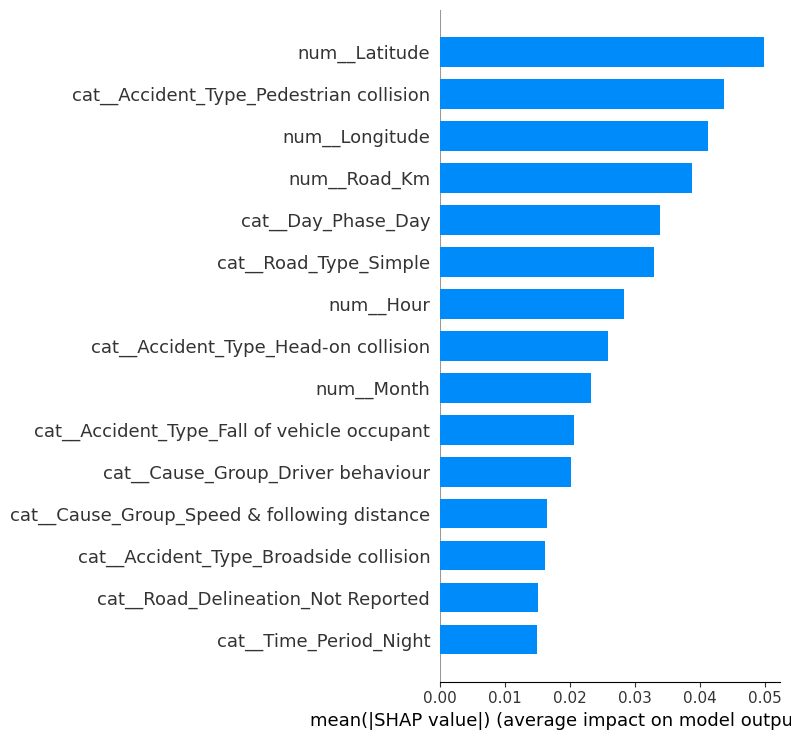

In [2]:
import time
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef, confusion_matrix,
)

RANDOM_STATE = 25
DATA_DIR   = Path.cwd().parent / 'data' / 'processed'
MODELS_DIR = Path.cwd().parent / 'models'

# Load
pipe   = joblib.load(MODELS_DIR / 'phase4_best_XGBoost_RandomOver.joblib')
X_test = pd.read_parquet(DATA_DIR / 'X_test.parquet')
y_test = pd.read_parquet(DATA_DIR / 'y_test.parquet')['Victims_Condition']

y_train_full = pd.read_parquet(DATA_DIR / 'y_train.parquet')['Victims_Condition']
_, class_labels = pd.factorize(y_train_full, sort=True)
y_test_int = pd.Categorical(y_test, categories=class_labels).codes

# Full test-set metrics
y_pred = pipe.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test_int, y_pred):.4f}")
print(f"Macro-F1 : {f1_score(y_test_int, y_pred, average='macro'):.4f}")
print(f"MCC      : {matthews_corrcoef(y_test_int, y_pred):.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_test_int, y_pred))

# Preprocessing for SHAP
preprocessor = pipe.named_steps['pre']
classifier   = pipe.named_steps['clf']
X_test_transformed = preprocessor.transform(X_test)
feature_names_ohe  = preprocessor.get_feature_names_out()

# STRATIFIED 10k sample — preserves 71.7/21.5/6.8 class ratio
_, sample_idx = train_test_split(
    np.arange(len(y_test_int)),
    test_size=10_000, stratify=y_test_int, random_state=RANDOM_STATE,
)
X_sample = X_test_transformed[sample_idx]

# TreeSHAP
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_sample)
print(f"SHAP shape: {shap_values.shape}")

# Global bar plot (still on raw OHE, still messy)
shap.summary_plot(
    shap_values.mean(axis=2),
    X_sample.toarray() if hasattr(X_sample, 'toarray') else X_sample,
    feature_names=feature_names_ohe,
    plot_type='bar', max_display=15,
)